## setup

In [1]:
from extraction import save_processed
%load_ext autoreload
%autoreload 2

import sys
import matplotlib.pyplot as plt
import seaborn as sns
from src.extraction import load_processed, save_model
from src.clustering import kmeans_grid_search ,apply_pca, check_cluster_balance, RANDOM_STATE, fit_final_kmeans, attach_labels
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import joblib

sys.path.append("..")
df_prepare_clustering = load_processed("df_prepare_clustering.csv")
df_prepare_clustering.shape

(8949, 7)

## run the grid search

In [2]:
grid_kmeans = kmeans_grid_search(df_prepare_clustering)
grid_kmeans.head(10)

,n_components,k,explained_variance,inertia,silhouette,min_cluster_pct,max_cluster_pct
0,2,3,0.646,13244.2,0.4487,27.1,37.9
1,2,2,0.646,23542.4,0.4310,31.3,68.7
2,2,4,0.646,10415.0,0.4217,19.3,30.8
3,2,5,0.646,8243.0,0.4101,15.6,27.7
4,3,6,0.760,11704.7,0.3986,5.8,23.3
5,2,7,0.646,5635.0,0.3979,11.0,19.8
6,2,6,0.646,6689.6,0.3947,11.9,27.0
7,3,5,0.760,13781.0,0.3909,15.8,24.2
8,3,4,0.760,16448.3,0.3888,20.9,27.9
9,3,3,0.760,20205.7,0.3826,26.7,39.9


## silhouette heatmap (components × k)

k,2,3,4,5,6,7
n_components,,,,,,
2,0.4310,0.4487,0.4217,0.4101,0.3947,0.3979
3,0.3683,0.3826,0.3888,0.3909,0.3986,0.3467
4,0.3246,0.3340,0.3266,0.3259,0.3287,0.3048
5,0.3046,0.3097,0.3066,0.3248,0.3208,0.2921


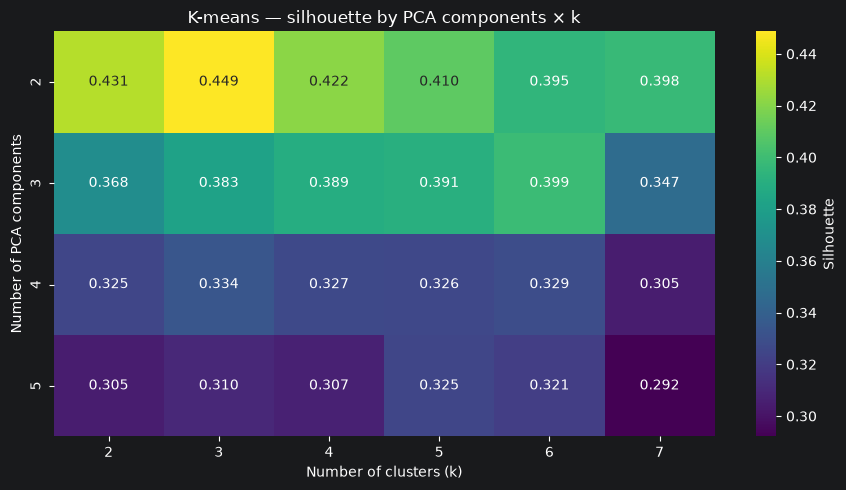

In [3]:
heatmap_data = grid_kmeans.pivot(index="n_components", columns="k", values="silhouette")
display(heatmap_data)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label" : "Silhouette"})
plt.title("K-means — silhouette by PCA components × k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Number of PCA components")
plt.tight_layout()
plt.savefig("../reports/figures/03_kmeans_grid_heatmap.png", dpi=100)
plt.show()

## Silhouette Interpretation
    > 0.5 Clear separation
    0.3 – 0.5 Reasonable structure
    < 0.25 Weak, clusters overlap

## best combinations that are also balanced

In [4]:
balanced = grid_kmeans[grid_kmeans["min_cluster_pct"] >= 10]
balanced.head(5)


,n_components,k,explained_variance,inertia,silhouette,min_cluster_pct,max_cluster_pct
0,2,3,0.646,13244.2,0.4487,27.1,37.9
1,2,2,0.646,23542.4,0.4310,31.3,68.7
2,2,4,0.646,10415.0,0.4217,19.3,30.8
3,2,5,0.646,8243.0,0.4101,15.6,27.7
5,2,7,0.646,5635.0,0.3979,11.0,19.8


## choose the number of components to study

In [5]:
best = balanced.iloc[0] # <- the best balanced combination.

N_COMPONENTS = int(best["n_components"])
K_CHOSEN = int(best["k"])

curves = grid_kmeans[grid_kmeans["n_components"] == N_COMPONENTS].sort_values("k")
curves[["k", "inertia", "silhouette", "min_cluster_pct", "max_cluster_pct"]]

,k,inertia,silhouette,min_cluster_pct,max_cluster_pct
1,2,23542.4,0.4310,31.3,68.7
0,3,13244.2,0.4487,27.1,37.9
2,4,10415.0,0.4217,19.3,30.8
3,5,8243.0,0.4101,15.6,27.7
6,6,6689.6,0.3947,11.9,27.0
5,7,5635.0,0.3979,11.0,19.8


## elbow curve and silhouette curve

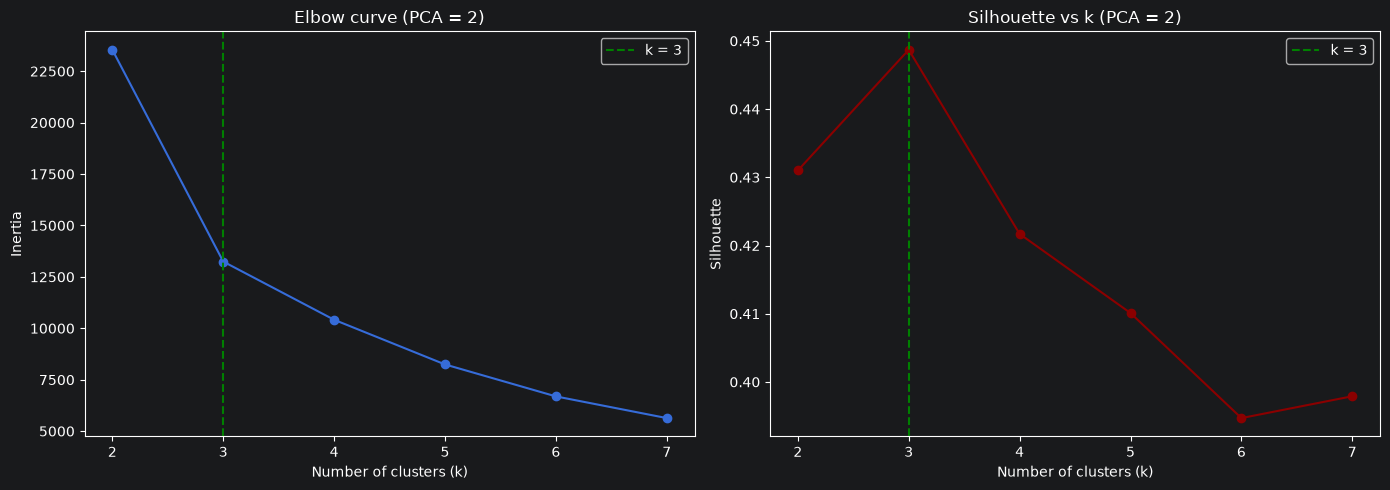

In [6]:
fix, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow: inertia vs k
axes[0].plot(curves["k"], curves["inertia"], marker="o")
axes[0].axvline(K_CHOSEN, color="green", linestyle="--", label=f"k = {K_CHOSEN}")
axes[0].set_title(f"Elbow curve (PCA = {N_COMPONENTS})")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

# Silhouette vs k
axes[1].plot(curves["k"], curves["silhouette"], marker="o", color="darkred")
axes[1].axvline(K_CHOSEN, color="green", linestyle="--", label=f"k = {K_CHOSEN}")
axes[1].set_title(f"Silhouette vs k (PCA = {N_COMPONENTS})")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/04_elbow_silhouette.png", dpi=100)
plt.show()

## balance check on the chosen combination

In [7]:
df_pca, _ = apply_pca(df_prepare_clustering, N_COMPONENTS)
labels = KMeans(n_clusters=K_CHOSEN, n_init=10, random_state=RANDOM_STATE).fit_predict(df_pca)

sizes, is_balanced = check_cluster_balance(labels)
print(f"balanced {is_balanced}")
sizes

balanced True


,count,pct
cluster,,
0,2428,27.1
1,3393,37.9
2,3128,35.0


## cluster sizes chart

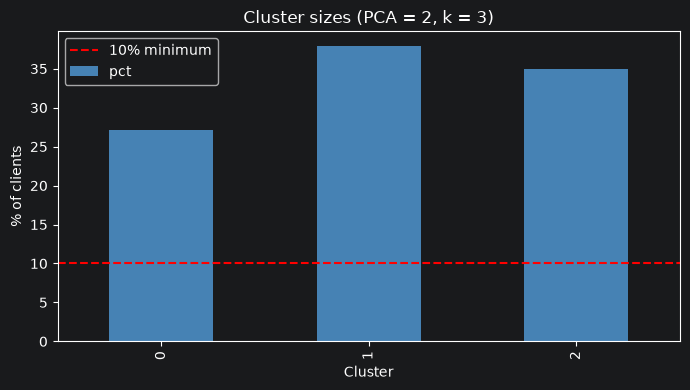

In [8]:
ax = sizes["pct"].plot(kind="bar", figsize=(7, 4), color="steelblue")
ax.axhline(10, color="red", linestyle="--", label="10% minimum")
ax.set_title(f"Cluster sizes (PCA = {N_COMPONENTS}, k = {K_CHOSEN})")
ax.set_xlabel("Cluster")
ax.set_ylabel("% of clients")
ax.legend()
plt.tight_layout()
plt.show()

## fit the final K-means

In [9]:
df_clean = load_processed("df_clean.csv")

labels, kmeans, pca_kmeans, df_pca = fit_final_kmeans(df_prepare_clustering, N_COMPONENTS, K_CHOSEN)

## attach the labels to df_clean

In [10]:
df_clean = attach_labels(df_clean, labels, "cluster_kmeans")
df_clean.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,cluster_kmeans
0,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084,2
1,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597,0
2,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742,1
3,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000,2
4,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763,2


## save the result and the model

In [ ]:
save_processed(df_clean, "df_clean_clusters.csv")

save_model({"pca": pca_kmeans, "kmeans": kmeans}, "kmeans_clustering.joblib")